# Analyse exploratoire - ElectricityConsumption

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Chargement de données

In [6]:
df = pd.read_csv("../data/processed/dataset_final.csv")
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df.head()


,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,1,2016,Hiver,...,5.531252,4.881011,95.60412,152.449308,0.894432,86.546508,0.0,False,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,1,2016,Hiver,...,5.531252,4.881011,95.60412,152.449308,0.894432,85.108657,0.0,False,True,3


In [3]:
print(df.shape)
df.head()


(94224, 28)


,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,1,2016,Hiver,...,7.161313,6.036176,92.69971,141.342131,1.398133,87.926456,0.0,False,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,1,2016,Hiver,...,5.531252,4.881011,95.60412,152.449308,0.894432,86.546508,0.0,False,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,1,2016,Hiver,...,5.531252,4.881011,95.60412,152.449308,0.894432,85.108657,0.0,False,True,3


## preparation

In [4]:
#ici le timestamp_utc serait lue comme du texte ,et il faut la convertir en vraie date pour pouvoir filtrer, trier ou grouper par jour 
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

In [5]:
#le jour calendaire à Paris
df["date"] = df["timestamp_utc"].dt.tz_convert("Europe/Paris").dt.tz_localize(None).dt.normalize()


## 0. Apercu

In [7]:
print("Période :", df["timestamp_utc"].min(), "->", df["timestamp_utc"].max())
print(df["consommation_mw"].describe().round(0))


Période : 2016-01-01 00:00:00+00:00 -> 2026-09-30 23:00:00+00:00
count    94224.0
mean     52158.0
std      11400.0
min      29364.0
25%      43609.0
50%      50312.0
75%      59694.0
max      96130.0
Name: consommation_mw, dtype: float64


In [8]:
print("Valeurs manquantes (conso) :", df["consommation_mw"].isna().sum())


Valeurs manquantes (conso) : 0


In [9]:
# Conso moyenne par année 
print(df.groupby("annee")["consommation_mw"].mean().round(0))

annee
2016    54680.0
2017    54685.0
2018    54282.0
2019    53707.0
2020    50840.0
2021    53491.0
2022    51386.0
2023    49722.0
2024    50100.0
2025    50671.0
2026    49511.0
Name: consommation_mw, dtype: float64


In [11]:
print(df["source_donnee"].value_counts())
print(df.groupby("source_donnee")["date"].agg(["min", "max"]))

source_donnee
Données définitives    78902
Données consolidées    13102
Données temps réel      2210
interpole                 10
Name: count, dtype: int64
                           min        max
source_donnee                            
Données consolidées 2025-01-01 2026-06-30
Données définitives 2016-01-01 2024-12-31
Données temps réel  2026-07-01 2026-10-01
interpole           2016-10-30 2025-10-26


In [12]:
# Qualité de la série : valeurs manquantes, doublons, trous
valeurs_manquantes = df.isna().sum()
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes > 0]
print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

print("\nTimestamps en doublon :", df["timestamp_utc"].duplicated().sum())
print("Fichier trié dans l'ordre chronologique :", df["timestamp_utc"].is_monotonic_increasing)

# on contrôle en UTC : chaque ligne doit tomber exactement 1 h après la précédente
print("\nIntervalles entre deux lignes consécutives :")
print(df["timestamp_utc"].diff().value_counts())

Nombre de valeurs manquantes par colonne :
confinement_numero    91009
dtype: int64

Timestamps en doublon : 0
Fichier trié dans l'ordre chronologique : True

Intervalles entre deux lignes consécutives :
timestamp_utc
0 days 01:00:00    94223
Name: count, dtype: int64


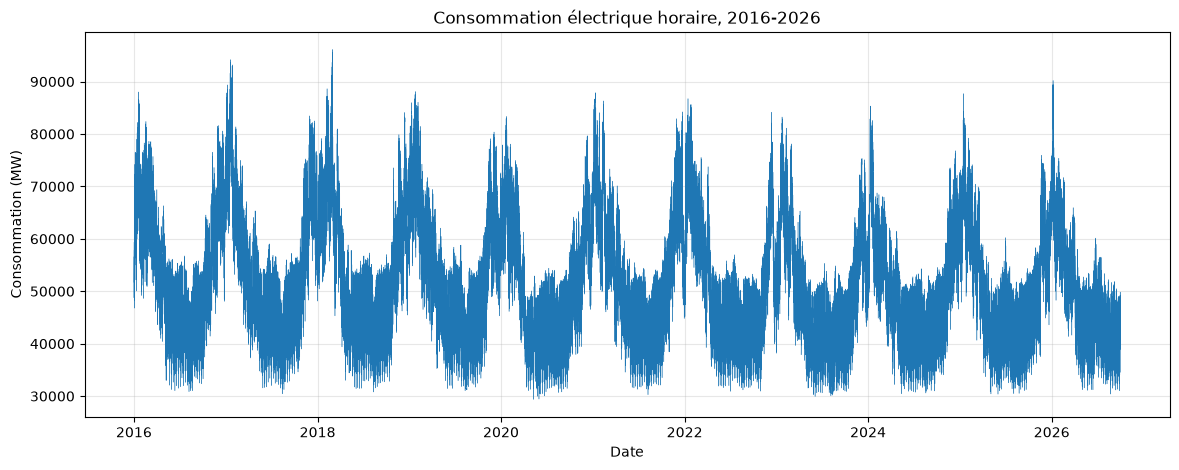

In [13]:
# Consommation horaire sur toute la période
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp_utc"], df["consommation_mw"], lw=.3)
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.title("Consommation électrique horaire, 2016-2026")
plt.grid(alpha=.3)
plt.show()

## 1. Cycle journalier

In [15]:
# Table journalière : une ligne par jour de Paris (sert à toutes les analyses à l'échelle du jour)
daily = df.groupby("date").agg(
    conso_moy=("consommation_mw", "mean"),
    conso_max=("consommation_mw", "max"),
    n_heures=("consommation_mw", "count"),
    temp=("temperature_c", "mean"),
    temp_pop=("temperature_c_pondere_pop", "mean"),
    jour_semaine=("jour_semaine", "first"),
    ferie=("ferie", "first"),
    saison=("saison", "first"),
    mois=("mois", "first"),
    annee=("annee", "first"),
    confinement=("confinement_numero", "max"),   # numéro du confinement (vide hors confinement)
    vacances=("vacances", "first"))

daily = daily[daily["n_heures"] >= 23]   # jours complets (23, 24 ou 25 heures) : écarte le dernier jour, tronqué

# daily contient TOUS les jours (confinements et fériés compris).

daily_hc = daily[daily["confinement"].isna()]
daily.head()

,conso_moy,conso_max,n_heures,temp,temp_pop,jour_semaine,ferie,saison,mois,annee,confinement,vacances
date,,,,,,,,,,,,
2016-01-01,53540.478261,59371.0,23,7.718645,7.201910,4,True,Hiver,1,2016,NaN,3
2016-01-02,55479.395833,63302.0,24,9.343269,8.992643,5,False,Hiver,1,2016,NaN,3
2016-01-03,56778.145833,65234.5,24,7.813141,7.317771,6,False,Hiver,1,2016,NaN,3
2016-01-04,64437.041667,74219.0,24,8.432372,8.200941,0,False,Hiver,1,2016,NaN,3
2016-01-05,67329.729167,76480.0,24,7.872436,7.626956,1,False,Hiver,1,2016,NaN,0


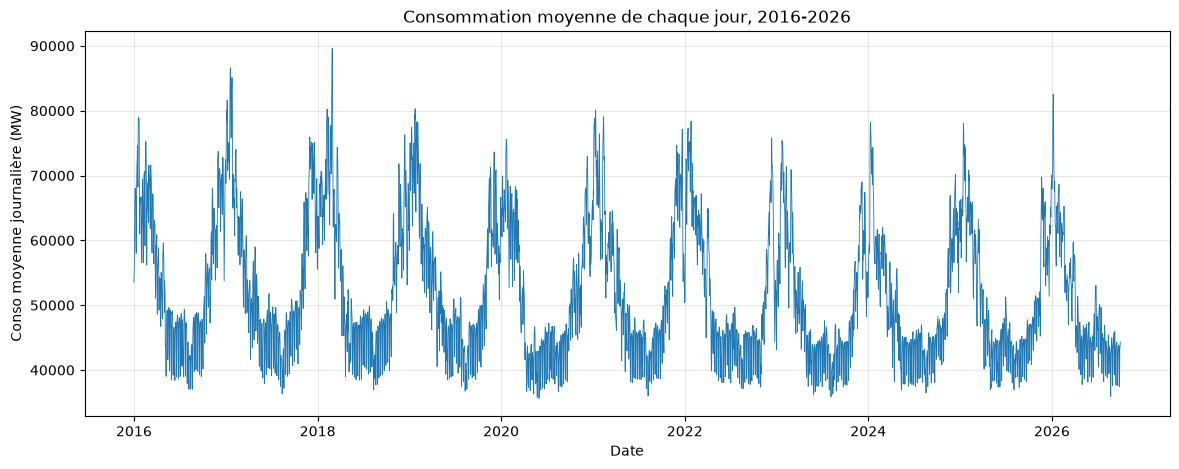

count     3926.0
mean     52159.0
std      10404.0
min      35619.0
25%      44338.0
50%      48654.0
75%      59805.0
max      89600.0
Name: conso_moy, dtype: float64
Jour le plus consommateur  : 2018-02-28 89600 MW
Jour le moins consommateur : 2020-05-31 35619 MW


In [16]:
# Une valeur par jour : conso moyenne de chaque jour de Paris sur toute la période
plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["conso_moy"], lw=.6)
plt.xlabel("Date")
plt.ylabel("Conso moyenne journalière (MW)")
plt.title("Consommation moyenne de chaque jour, 2016-2026")
plt.grid(alpha=.3)
plt.show()

print(daily["conso_moy"].describe().round(0))
print("Jour le plus consommateur  :", daily["conso_moy"].idxmax().date(), round(daily["conso_moy"].max()), "MW")
print("Jour le moins consommateur :", daily["conso_moy"].idxmin().date(), round(daily["conso_moy"].min()), "MW")

C:\Users\bahri\AppData\Local\Temp\ipykernel_21152\1221498337.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color="grey", alpha=.2)


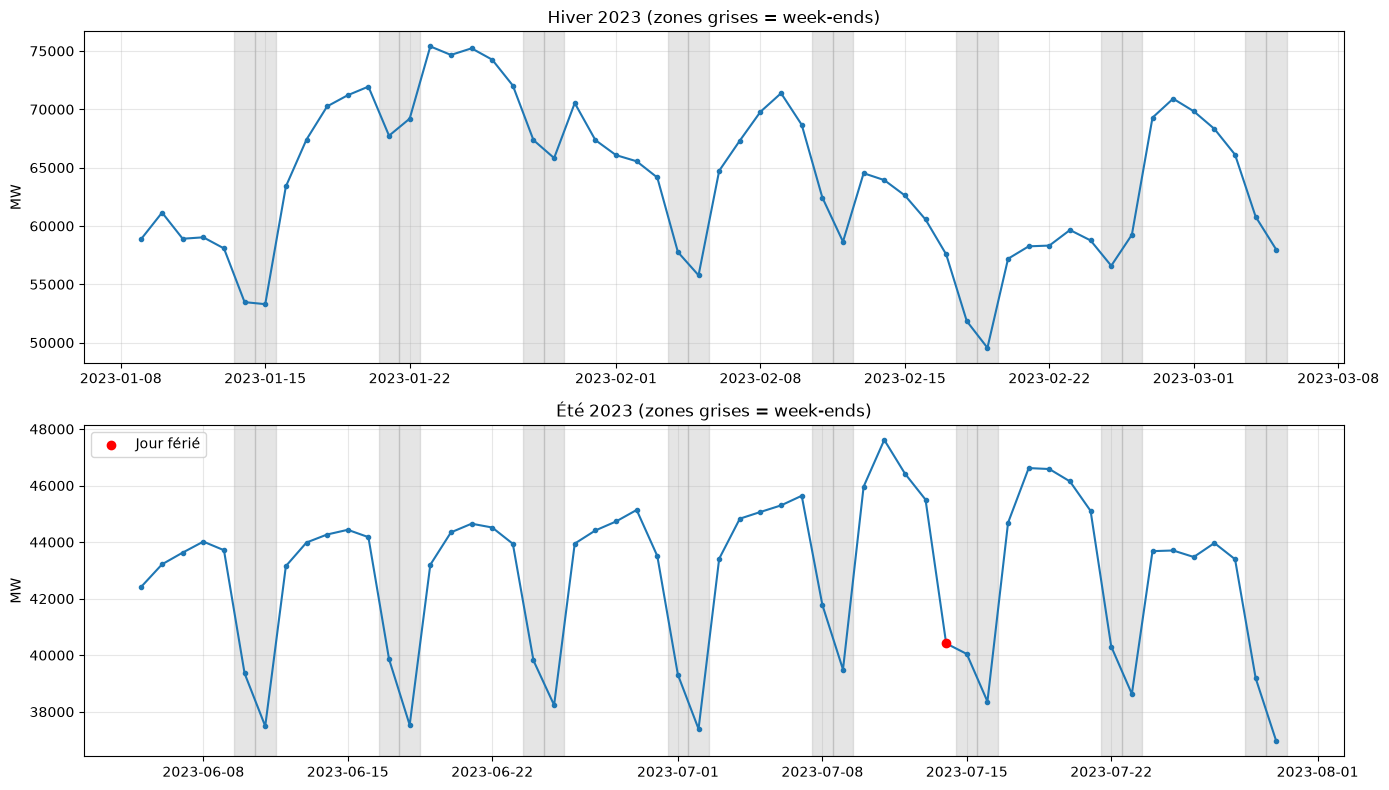

In [17]:
# Zoom sur 8 semaines d'hiver et 8 semaines d'été : le rythme jour après jour
fenetres = [("2023-01-09", "2023-03-05", "Hiver 2023"),
            ("2023-06-05", "2023-07-30", "Été 2023")]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, (debut, fin, titre) in zip(axes, fenetres):
    f = daily.loc[debut:fin]
    ax.plot(f.index, f["conso_moy"], marker="o", ms=3)
    for d in f.index[f["jour_semaine"] >= 5]:                       # week-ends en gris
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color="grey", alpha=.2)
    feries = f[f["ferie"]]
    ax.scatter(feries.index, feries["conso_moy"], color="red", zorder=3, label="Jour férié")
    ax.set_title(titre + " (zones grises = week-ends)")
    ax.set_ylabel("MW")
    ax.grid(alpha=.3)
axes[1].legend()
plt.tight_layout()
plt.show()

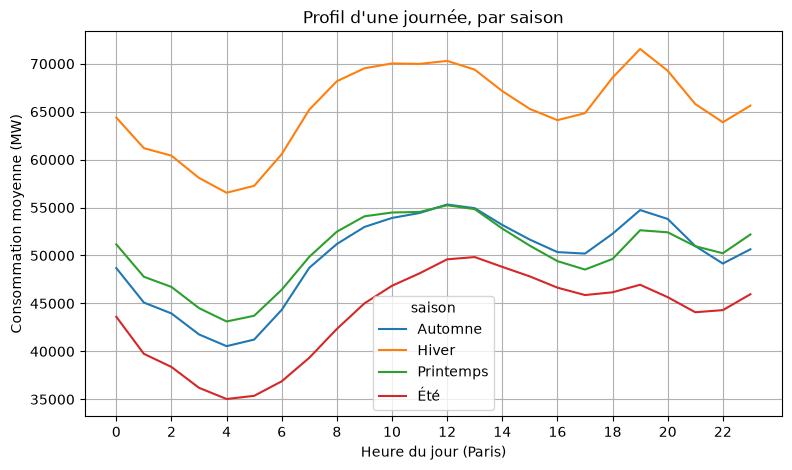

Heure du pic   : {'Automne': 12, 'Hiver': 19, 'Printemps': 12, 'Été': 13}
Heure du creux : {'Automne': 4, 'Hiver': 4, 'Printemps': 4, 'Été': 4}
Amplitude pic - creux (MW) : {'Automne': 14773.0, 'Hiver': 14991.0, 'Printemps': 12121.0, 'Été': 14805.0}
Écart hiver - été (MW), heures 4, 13 et 19 : {4: 21515.0, 13: 19548.0, 19: 24591.0}


In [18]:
# Profil d'une journée par saison : conso moyenne de chaque heure (toutes les heures de la période)
profil = df.groupby(["saison", "heure"])["consommation_mw"].mean().unstack(0)

profil.plot(figsize=(9, 5), xticks=range(0, 24, 2), grid=True)
plt.xlabel("Heure du jour (Paris)")
plt.ylabel("Consommation moyenne (MW)")
plt.title("Profil d'une journée, par saison")
plt.show()

print("Heure du pic   :", profil.idxmax().to_dict())
print("Heure du creux :", profil.idxmin().to_dict())
print("Amplitude pic - creux (MW) :", (profil.max() - profil.min()).round(0).to_dict())
print("Écart hiver - été (MW), heures 4, 13 et 19 :", (profil["Hiver"] - profil["Été"]).loc[[4, 13, 19]].round(0).to_dict())

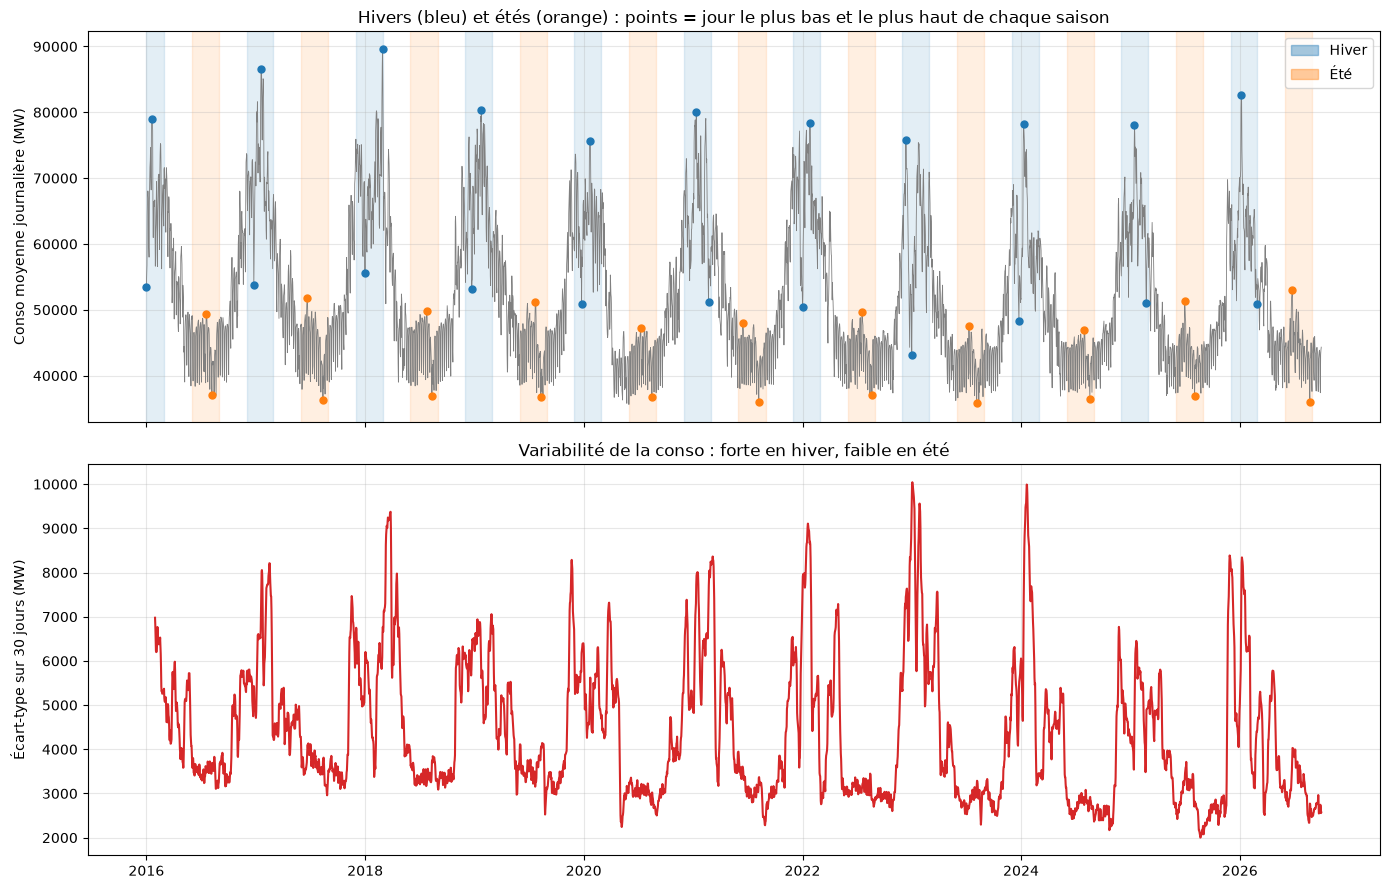

            min      q05      q95      max  ecart_type  etendue_5_95
saison                                                              
Hiver   43105.0  53688.0  77721.0  89600.0      7284.0       24033.0
Été     35864.0  37864.0  48760.0  53033.0      3441.0       10897.0


In [19]:
from matplotlib.patches import Patch

couleurs = {"Hiver": "tab:blue", "Été": "tab:orange"}

fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Haut : la série journalière, avec les hivers et les étés en couleur et leurs extrêmes marqués
ax[0].plot(daily.index, daily["conso_moy"], lw=.6, color="grey")

bloc = (daily["saison"] != daily["saison"].shift()).cumsum()    # un bloc = une saison d'une année
for _, g in daily.groupby(bloc):
    saison = g["saison"].iloc[0]
    if saison in couleurs:
        ax[0].axvspan(g.index.min(), g.index.max(), color=couleurs[saison], alpha=.12)
        for jour in (g["conso_moy"].idxmin(), g["conso_moy"].idxmax()):      # jour le plus bas et le plus haut
            ax[0].scatter(jour, g.loc[jour, "conso_moy"], color=couleurs[saison], s=25, zorder=3)

ax[0].set_ylabel("Conso moyenne journalière (MW)")
ax[0].set_title("Hivers (bleu) et étés (orange) : points = jour le plus bas et le plus haut de chaque saison")
ax[0].legend(handles=[Patch(color=c, alpha=.4, label=s) for s, c in couleurs.items()])
ax[0].grid(alpha=.3)

# Bas : écart-type glissant sur 30 jours = mesure de la variabilité au fil du temps
ax[1].plot(daily.index, daily["conso_moy"].rolling(30).std(), color="tab:red")
ax[1].set_ylabel("Écart-type sur 30 jours (MW)")
ax[1].set_title("Variabilité de la conso : forte en hiver, faible en été")
ax[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

# Les mêmes chiffres en tableau (tous les jours)
saisons = daily[daily["saison"].isin(couleurs)]
stats = saisons.groupby("saison")["conso_moy"].agg(
    min="min", q05=lambda x: x.quantile(.05), q95=lambda x: x.quantile(.95), max="max", ecart_type="std")
stats["etendue_5_95"] = stats["q95"] - stats["q05"]
print(stats.round(0))

- l'écart-type glissant atteint 7 000 à 10 000 MW à chaque hiver, et redescend à 2 000-4 000 MW en été. C'est la preuve visuelle d'une variance qui dépend de la saison

- En haut, dans chaque bande bleue, les deux points sont très éloignés : un jour très haut en pleine vague de froid et un jour bas. Dans les bandes orange, les deux points restent proches.

- Les points bleus bas sont probablement des jours de congés, comme Noël ou le 1er janvier.

## 2. Cycle hebdomadaire

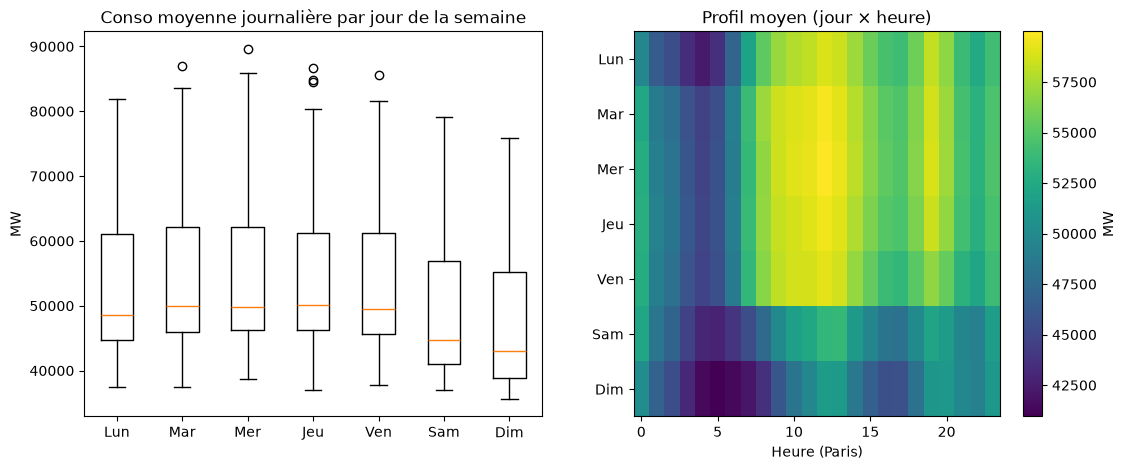

jour_semaine
Lun    52881.0
Mar    54153.0
Mer    54258.0
Jeu    54121.0
Ven    53575.0
Sam    49074.0
Dim    47054.0
Name: conso_moy, dtype: float64
Semaine (lun-ven) vs dimanche : +14.3%
Lundi vs mar-jeu : -2.4% | Vendredi vs mar-jeu : -1.1%


In [20]:
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].boxplot([daily.loc[daily["jour_semaine"] == i, "conso_moy"] for i in range(7)])
ax[0].set_xticklabels(jours)
ax[0].set_title("Conso moyenne journalière par jour de la semaine")
ax[0].set_ylabel("MW")

heat = df.groupby(["jour_semaine", "heure"])["consommation_mw"].mean().unstack()
im = ax[1].imshow(heat.values, aspect="auto", cmap="viridis")
ax[1].set_yticks(range(7))
ax[1].set_yticklabels(jours)
ax[1].set_xlabel("Heure (Paris)")
ax[1].set_title("Profil moyen (jour × heure)")
plt.colorbar(im, ax=ax[1], label="MW")
plt.show()

m = daily.groupby("jour_semaine")["conso_moy"].mean()
print(m.round(0).rename(dict(enumerate(jours))))
print(f"Semaine (lun-ven) vs dimanche : {m.loc[0:4].mean() / m.loc[6] - 1:+.1%}")
print(f"Lundi vs mar-jeu : {m.loc[0] / m.loc[1:3].mean() - 1:+.1%} | "
      f"Vendredi vs mar-jeu : {m.loc[4] / m.loc[1:3].mean() - 1:+.1%}")

- Le cycle hebdomadaire a trois niveaux : un plateau en semaine (mardi-jeudi ≈ 54 177 MW), un samedi plus bas (49 074 MW, soit −5 103 MW ou −9,4 %) et un dimanche encore plus bas (47 054 MW, soit −7 123 MW ou −13,1 %). La semaine (lundi-vendredi, 53 798 MW en moyenne) dépasse le dimanche de 6 744 MW, soit +14,3 %.

- Lundi (52 881 MW, −1 296 MW ou −2,4 % par rapport à mardi-jeudi) et vendredi (53 575 MW, −602 MW ou −1,1 %) sont à peine plus bas. L'effet de transition existe mais reste faible à côté du week-end. Le creux du lundi est un peu amplifié par les lundis fériés (Pâques, Pentecôte, etc.) et les jours de confinement.

Boîtes à moustaches :
- La largeur des boîtes vient de la saisonnalité annuelle et de la météo, pas du jour de la semaine.
- Les médianes (≈ 48 500 MW le lundi, ≈ 50 000 MW de mardi à vendredi, ≈ 44 700 MW le samedi, ≈ 43 000 MW le dimanche) sont sous les moyennes : distribution asymétrique à droite, tirée par les pics d'hiver.
- Les points isolés au-dessus des moustaches (mardi à vendredi) sont des journées de grand froid ; le plus haut, ≈ 89 600 MW le mercredi, est le 28 février 2018. Aucun point isolé bas : les fériés et les jours de Covid se confondent avec les jours ordinaires d'été.

Carte jour × heure :
- Les jours ouvrés, surtout mardi à jeudi, sont les plus clairs : une montée entre 6 h et 9 h, un plateau de 10 h à 13 h autour de 60 000 MW, un léger creux vers 16 h-17 h, puis la pointe de 19 h.
- Le dimanche est la ligne la plus foncée, avec le minimum de la semaine (≈ 41 000 MW) entre 3 h et 6 h.
- Le samedi n'a pas de montée franche le matin, et la pointe du soir est plus discrète.
- Le lundi est plus foncé que les autres jours de semaine en début de matinée : la nuit de dimanche à lundi prolonge le niveau du week-end (avec, en plus, un petit effet des lundis fériés).

## 3. Cycle annuelle et tendance

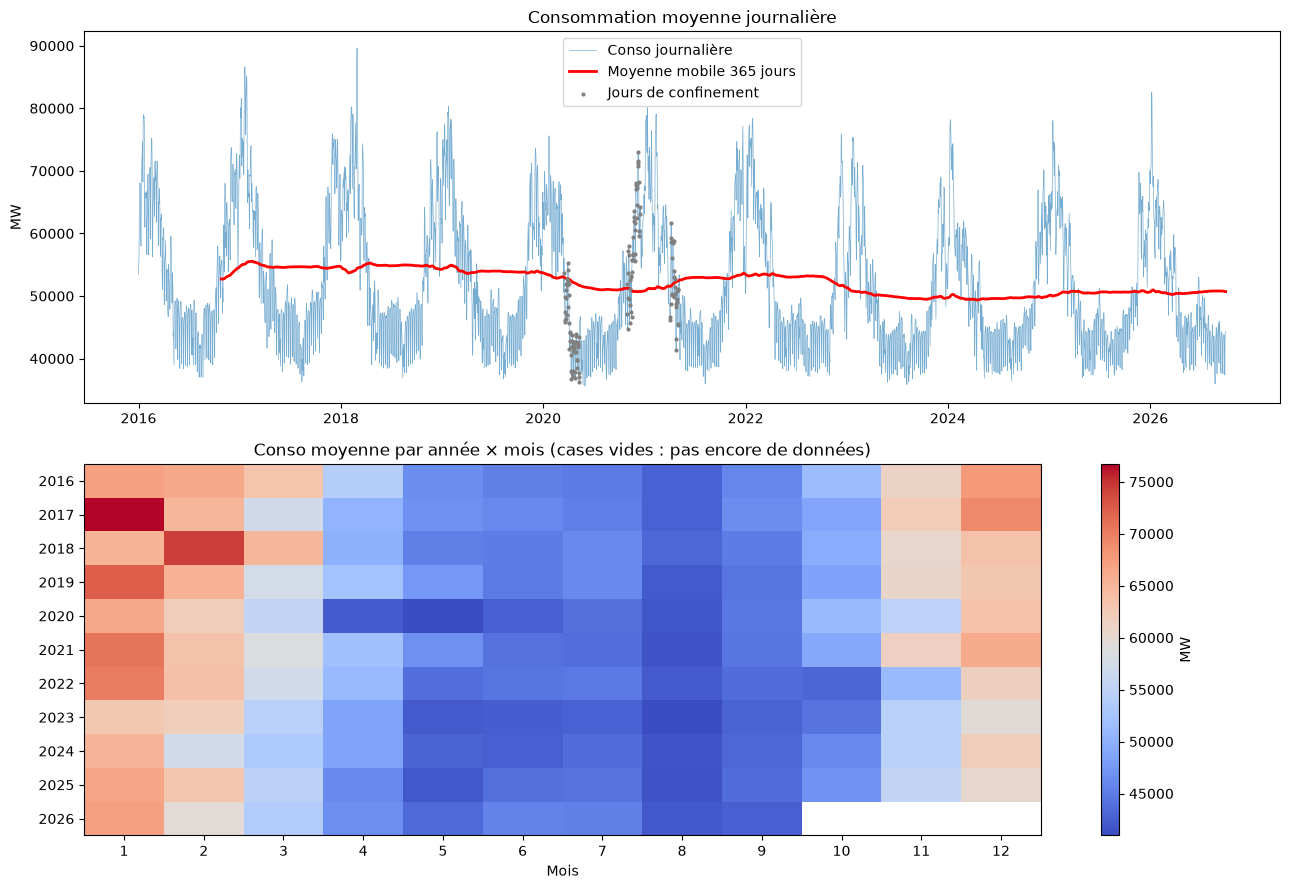

mois
1     68195.0
2     63786.0
3     57351.0
4     49337.0
5     44388.0
6     44291.0
7     44681.0
8     42118.0
9     44283.0
10    47916.0
11    57675.0
12    63629.0
Name: conso_moy, dtype: float64
Ratio janvier / (juillet-août) : 1.57


In [24]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9))

ax[0].plot(daily.index, daily["conso_moy"], lw=.5, alpha=.6, label="Conso journalière")
ax[0].plot(daily["conso_moy"].rolling(365, min_periods=300).mean(),
           color="red", lw=2, label="Moyenne mobile 365 jours")
covid = daily[daily["confinement"].notna()]
ax[0].scatter(covid.index, covid["conso_moy"], s=4, color="grey", label="Jours de confinement", zorder=3)
ax[0].set_title("Consommation moyenne journalière")
ax[0].set_ylabel("MW")
ax[0].legend()

mm = daily.groupby(["annee", "mois"])["conso_moy"].mean().unstack()
im = ax[1].imshow(mm.values, aspect="auto", cmap="coolwarm")
ax[1].set_yticks(range(len(mm.index)))
ax[1].set_yticklabels(mm.index)
ax[1].set_xticks(range(12))
ax[1].set_xticklabels(range(1, 13))
ax[1].set_xlabel("Mois")
ax[1].set_title("Conso moyenne par année × mois (cases vides : pas encore de données)")
plt.colorbar(im, ax=ax[1], label="MW")
plt.tight_layout()
plt.show()

mo = daily.groupby("mois")["conso_moy"].mean()
print(mo.round(0))
print(f"Ratio janvier / (juillet-août) : {mo.loc[1] / mo.loc[[7, 8]].mean():.2f}")

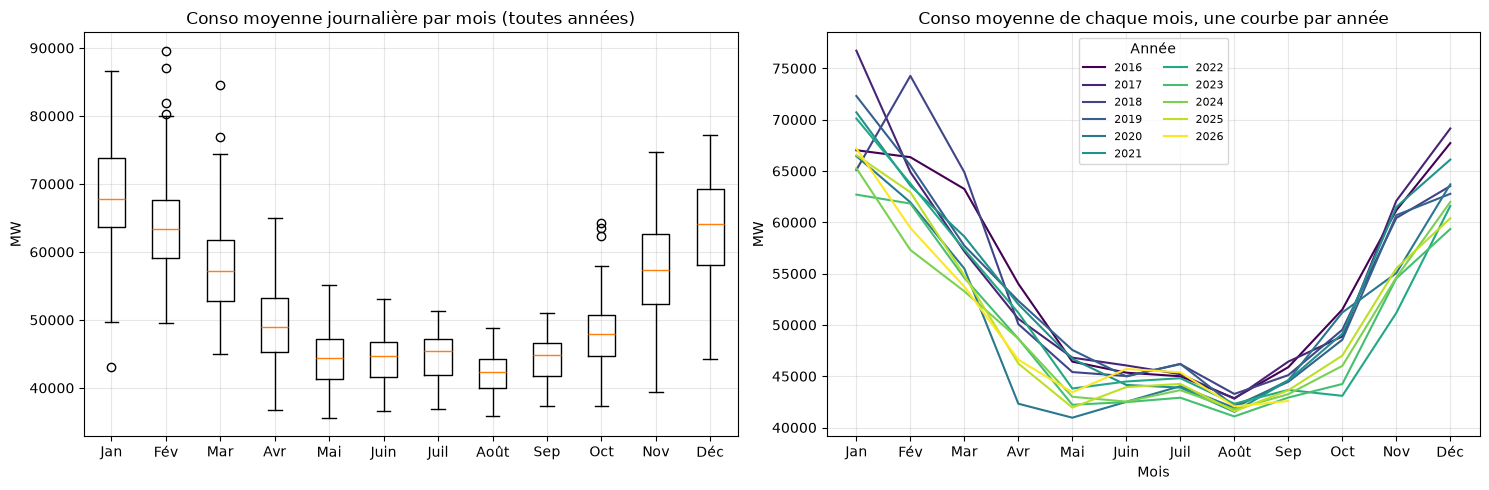

Mois le plus consommateur : Jan 68195 MW
Mois le moins consommateur : Août 42118 MW


In [25]:
mois_noms = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gauche : la conso de chaque jour, regroupée par mois (toutes années, tous les jours)
ax[0].boxplot([daily.loc[daily["mois"] == m, "conso_moy"] for m in range(1, 13)])
ax[0].set_xticklabels(mois_noms)
ax[0].set_title("Conso moyenne journalière par mois (toutes années)")
ax[0].set_ylabel("MW")
ax[0].grid(alpha=.3)

# Droite : une courbe par année = conso moyenne de chaque mois
par_annee = daily.groupby(["annee", "mois"])["conso_moy"].mean().unstack(0)
par_annee.plot(ax=ax[1], colormap="viridis")
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(mois_noms)
ax[1].set_xlabel("Mois")
ax[1].set_ylabel("MW")
ax[1].set_title("Conso moyenne de chaque mois, une courbe par année")
ax[1].legend(title="Année", ncol=2, fontsize=8)
ax[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

mo = daily.groupby("mois")["conso_moy"].mean()
print("Mois le plus consommateur :", mois_noms[mo.idxmax() - 1], round(mo.max()), "MW")
print("Mois le moins consommateur :", mois_noms[mo.idxmin() - 1], round(mo.min()), "MW")

- Saisonnalité annuelle : maximum en janvier (68 195 MW), minimum en août (42 118 MW), ratio janvier / (juillet-août) = 1,57. Plateau très stable de mai à septembre (≈ 44,3–44,7 GW), puis chute en août (vacances).
- Décembre (63,6 GW) est plus bas que janvier (68,2 GW) : effet des vacances de Noël.

- Seul le premier confinement (printemps 2020) est visible à l'œil ; l'effet des deux suivants est masqué par la météo d'hiver.
- les pics d'hiver varient fortement d'une année à l'autre (jan. 2017, fév. 2018), les étés sont très stables.


In [26]:
# Tendance : moyenne de chaque année civile (2026 incomplète, donc non comparable)
moy_annuelle = df.groupby("annee")["consommation_mw"].mean().round(0)
print(moy_annuelle)
print(f"2016 -> 2025 : {moy_annuelle.loc[2025] - moy_annuelle.loc[2016]:+.0f} MW ({moy_annuelle.loc[2025] / moy_annuelle.loc[2016] - 1:+.1%})")
print(f"2016 -> 2023 : {moy_annuelle.loc[2023] - moy_annuelle.loc[2016]:+.0f} MW ({moy_annuelle.loc[2023] / moy_annuelle.loc[2016] - 1:+.1%})")

# Pour lire le détail d'un mois (par exemple janvier 2017, février 2018, avril-mai 2020) :
print(par_annee.loc[[1, 2, 4, 5]].round(0))

annee
2016    54680.0
2017    54685.0
2018    54282.0
2019    53707.0
2020    50840.0
2021    53491.0
2022    51386.0
2023    49722.0
2024    50100.0
2025    50671.0
2026    49511.0
Name: consommation_mw, dtype: float64
2016 -> 2025 : -4009 MW (-7.3%)
2016 -> 2023 : -4958 MW (-9.1%)
annee     2016     2017     2018     2019     2020     2021     2022     2023  \
mois                                                                            
1      67023.0  76722.0  65103.0  72308.0  66452.0  70716.0  70114.0  62698.0   
2      66346.0  64895.0  74268.0  65539.0  61948.0  63568.0  63779.0  61826.0   
4      54009.0  50595.0  50079.0  52346.0  42322.0  52011.0  51183.0  48655.0   
5      46423.0  46811.0  45407.0  47560.0  40960.0  46693.0  43803.0  42221.0   

annee     2024     2025     2026  
mois                              
1      65266.0  66550.0  67192.0  
2      57305.0  62928.0  59455.0  
4      48658.0  46239.0  46613.0  
5      42999.0  41952.0  43436.0  


## 4. Relation conso / meteo

temp      R² = 0.815 | minimum de conso à 22.0 °C | pente à froid (<12 °C) = -2185 MW/°C | pente à chaud (>20 °C) = 464 MW/°C
temp_pop  R² = 0.809 | minimum de conso à 22.3 °C | pente à froid (<12 °C) = -2080 MW/°C | pente à chaud (>20 °C) = 446 MW/°C


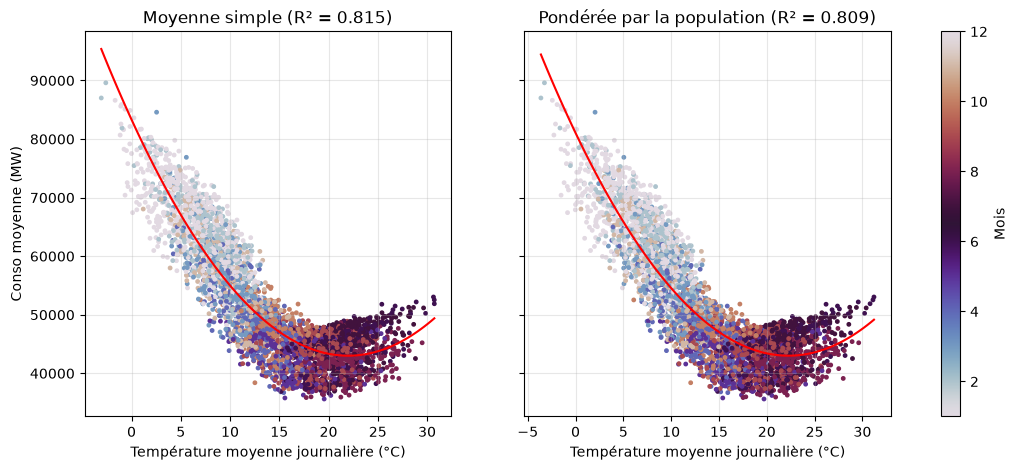

temperature_c                0
temperature_c_pondere_pop    0
dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col, titre in zip(axes, ["temp", "temp_pop"], ["Moyenne simple", "Pondérée par la population"]):
    d = daily[[col, "conso_moy", "mois"]].dropna()
    x, y = d[col], d["conso_moy"]

    sc = ax.scatter(x, y, c=d["mois"], cmap="twilight", s=6)

    # parabole ajustée sur le nuage : son R² mesure la netteté de la relation en U
    a, b, c = np.polyfit(x, y, 2)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, a * xs**2 + b * xs + c, color="red")
    r2 = 1 - ((y - (a * x**2 + b * x + c))**2).sum() / ((y - y.mean())**2).sum()

    ax.set_title(f"{titre} (R² = {r2:.3f})")
    ax.set_xlabel("Température moyenne journalière (°C)")
    ax.grid(alpha=.3)

    froid, chaud = x < 12, x > 20
    print(f"{col:9s} R² = {r2:.3f} | minimum de conso à {-b / (2 * a):.1f} °C | "
          f"pente à froid (<12 °C) = {np.polyfit(x[froid], y[froid], 1)[0]:.0f} MW/°C | "
          f"pente à chaud (>20 °C) = {np.polyfit(x[chaud], y[chaud], 1)[0]:.0f} MW/°C")

axes[0].set_ylabel("Conso moyenne (MW)")
fig.colorbar(sc, ax=axes, label="Mois")
plt.show()

print(df[["temperature_c", "temperature_c_pondere_pop"]].isna().sum())   # heures sans mesure

In [28]:
# Comparaison avec / sans : le R² baisse-t-il quand on garde les week-ends, fériés et confinements ?
cas = {
    "Tous les jours": daily,
    "Jours ouvrés, sans férié ni confinement": daily_hc[(daily_hc["jour_semaine"] < 5) & (~daily_hc["ferie"])],
}
for nom, d in cas.items():
    d = d[["temp_pop", "conso_moy"]].dropna()
    a, b, c = np.polyfit(d["temp_pop"], d["conso_moy"], 2)
    pred = a * d["temp_pop"]**2 + b * d["temp_pop"] + c
    r2 = 1 - ((d["conso_moy"] - pred)**2).sum() / ((d["conso_moy"] - d["conso_moy"].mean())**2).sum()
    print(f"{nom:42s} n = {len(d):4d} | R² = {r2:.3f}")

Tous les jours                             n = 3926 | R² = 0.809
Jours ouvrés, sans férié ni confinement    n = 2620 | R² = 0.882


- Une relation en U, très nette. La température seule explique environ 81 % de la variance de la consommation journalière. La consommation baisse quand la température monte jusqu'à environ 22 °C, puis remonte légèrement.

- Pente à froid : chaque degré en moins ajoute environ 2 100 à 2 200 MW. C'est le chauffage électrique.
- Pente à chaud (> 20 °C) : +464 et +446 MW/°C, soit ≈ 5 fois moins (climatisation peu développée).

- La parabole surestime aux extrêmes. À −3 °C, elle donne ≈ 95 000 MW alors que les points les plus froids sont vers 87 000 à 90 000 MW. Une forme par morceaux (une pente en dessous d'un seuil, une autre au-dessus) collerait mieux qu'une parabole. On le testera dans les modèles avec des variables du type « degrés sous 15 °C » et « degrés au-dessus de 22 °C ».
La dispersion augmente quand il fait froid

## 5. Effets calendaires

Écart de conso : jour férié vs jour non férié, même jour de semaine
  Lun : n= 36  écart = -17.4%
  Mar : n= 11  écart = -16.8%
  Mer : n= 13  écart = -12.0%
  Jeu : n= 21  écart = -18.5%
  Ven : n= 14  écart = -13.7%


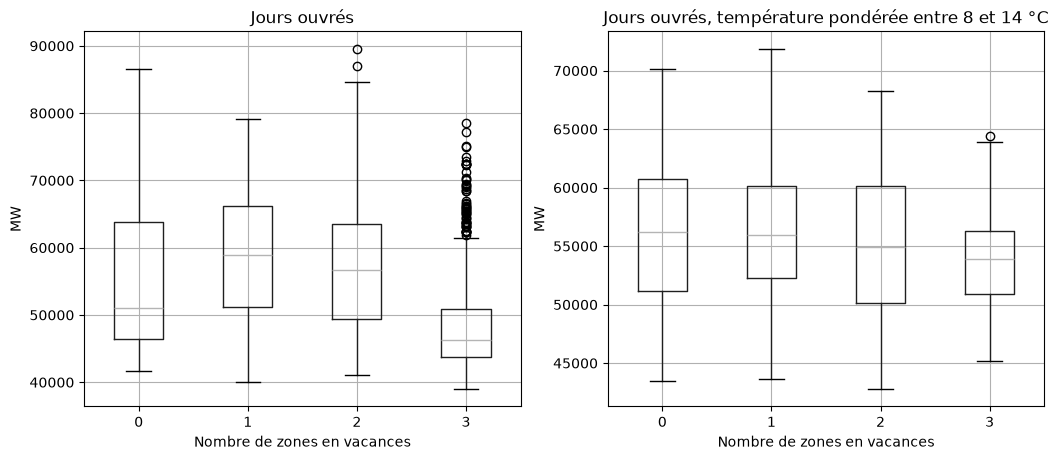

          count     mean
vacances                
0          1666  55275.0
1           201  58365.0
2           205  57249.0
3           637  48666.0
          count     mean
vacances                
0           526  55988.0
1            98  56074.0
2           126  55428.0
3           115  53918.0


In [ ]:
semaine = daily[daily["jour_semaine"] < 5]

print("Écart de conso : jour férié vs jour non férié, même jour de semaine")
for i in range(5):
    f = semaine[(semaine["jour_semaine"] == i) & semaine["ferie"]]["conso_moy"]
    n = semaine[(semaine["jour_semaine"] == i) & ~semaine["ferie"]]["conso_moy"]
    if len(f) > 3:
        print(f"  {jours[i]} : n={len(f):3d}  écart = {f.mean() / n.mean() - 1:+.1%}")

jours_ouvres = daily[(daily["jour_semaine"] < 5) & (~daily["ferie"])]
frais = jours_ouvres[(jours_ouvres["temp_pop"] > 8) & (jours_ouvres["temp_pop"] < 14)]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
jours_ouvres.boxplot(column="conso_moy", by="vacances", ax=ax[0])
ax[0].set_title("Jours ouvrés")
frais.boxplot(column="conso_moy", by="vacances", ax=ax[1])
ax[1].set_title("Jours ouvrés, température pondérée entre 8 et 14 °C")
for a in ax:
    a.set_xlabel("Nombre de zones en vacances")
    a.set_ylabel("MW")
plt.suptitle("")
plt.show()

print(jours_ouvres.groupby("vacances")["conso_moy"].agg(["count", "mean"]).round(0))
print(frais.groupby("vacances")["conso_moy"].agg(["count", "mean"]).round(0))

In [30]:
# Contrôle du calendrier des vacances : le dernier jour de chaque période devrait surtout tomber un dimanche
fin = daily[(daily["vacances"] > 0) & (daily["vacances"].shift(-1) == 0)]
print(fin["jour_semaine"].value_counts())

exceptions = fin[fin["jour_semaine"] != 6]
print(exceptions[["jour_semaine", "vacances"]])

jour_semaine
6    47
0     8
2     3
3     2
1     2
Name: count, dtype: int64
            jour_semaine  vacances
date                              
2016-01-04             0         3
2016-03-07             0         1
2016-05-02             0         1
2016-08-31             2         3
2016-11-03             3         3
2017-01-03             1         3
2017-03-06             0         1
2017-05-02             1         1
2017-08-31             3         3
2020-08-31             0         3
2021-09-01             2         3
2022-08-31             2         3
2023-01-02             0         3
2023-05-08             0         1
2026-08-31             0         3


- Effet des jours fériés : à jour de semaine égal, un férié consomme 12 à 18 % de moins qu'un jour normal 

- Effet des vacances : sur tous les jours ouvrés, 3 zones en vacances donnent 48 666 MW contre 55 275 MW sans vacances (−12 %), mais c'est surtout un effet de saison (vacances d'été sans chauffage), alors que les vacances d'hiver et de printemps (1 ou 2 zones) tombent en période de chauffage (58 365 et 57 249 MW).  L'effet vacances est donc faible par rapport à celui du week-end et des fériés, et en partie lié à la température résiduelle de la fenêtre.

## 6. Ruptures et observations atypiques

           jour  écart    z  ferie  confinement
date                                           
2022-12-11  Dim  0.360  6.9  False          NaN
2022-12-17  Sam  0.353  6.7  False          NaN
2025-11-22  Sam  0.350  6.7  False          NaN
2024-01-20  Sam  0.344  6.6  False          NaN
2023-01-22  Dim  0.343  6.6  False          NaN
2022-12-18  Dim  0.337  6.4  False          NaN
2022-12-12  Lun  0.329  6.3  False          NaN
2023-01-01  Dim -0.311 -5.9   True          NaN
2024-01-10  Mer  0.309  5.9  False          NaN
2021-02-13  Sam  0.307  5.9  False          NaN
2022-12-10  Sam  0.302  5.8  False          NaN
2025-11-23  Dim  0.299  5.7  False          NaN
2024-01-11  Jeu  0.298  5.7  False          NaN
2025-11-21  Ven  0.298  5.7  False          NaN
2026-01-06  Mar  0.292  5.6  False          NaN
2024-01-12  Ven  0.292  5.6  False          NaN
2026-01-07  Mer  0.289  5.5  False          NaN
2024-01-19  Ven  0.289  5.5  False          NaN
2024-01-13  Sam  0.288  5.5  False      

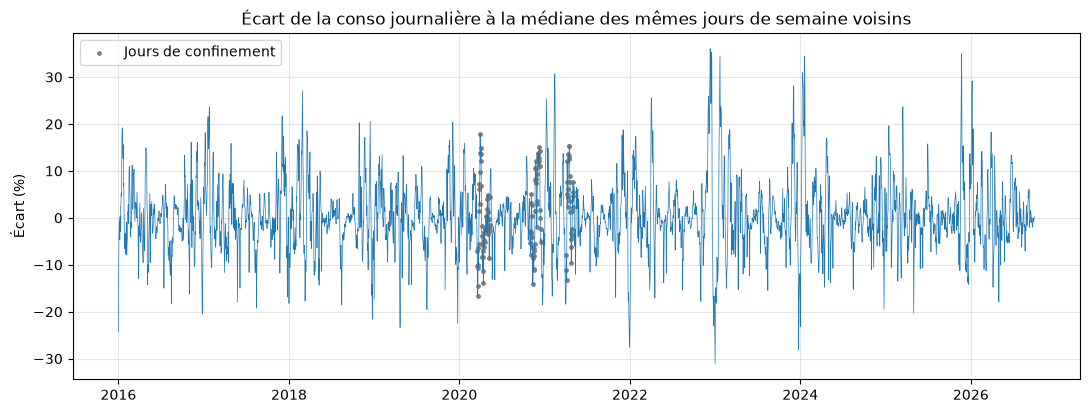

In [32]:
# Écart de chaque jour à la médiane des mêmes jours de semaine voisins (±4 semaines)
# asfreq("D") remet les jours absents (NaN) pour que les décalages de 7 jours tombent bien sur le même jour de semaine
s = daily["conso_moy"].asfreq("D")
ref = pd.concat([s.shift(7 * k) for k in (-4, -3, -2, -1, 1, 2, 3, 4)], axis=1).median(axis=1)
resid = (s / ref - 1).dropna()
z = (resid - resid.median()) / (1.4826 * (resid - resid.median()).abs().median())

top = z.abs().sort_values(ascending=False).head(20).index
atypiques = pd.DataFrame({
    "jour": daily.loc[top, "jour_semaine"].map(dict(enumerate(jours))),
    "écart": resid[top].round(3),
    "z": z[top].round(1),
    "ferie": daily.loc[top, "ferie"],
    "confinement": daily.loc[top, "confinement"]})
print(atypiques)

plt.figure(figsize=(13, 4.5))
plt.plot(resid.index, resid * 100, lw=.5)
covid_idx = resid.index[daily.loc[resid.index, "confinement"].notna().values]
plt.scatter(covid_idx, resid[covid_idx] * 100, s=6, color="grey", label="Jours de confinement")
plt.ylabel("Écart (%)")
plt.title("Écart de la conso journalière à la médiane des mêmes jours de semaine voisins")
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [33]:
# Maximum horaire de chaque année
pics = df.loc[df.groupby("annee")["consommation_mw"].idxmax(), ["timestamp_paris", "consommation_mw"]]
print(pics.to_string(index=False))

          timestamp_paris  consommation_mw
2016-01-18 19:00:00+01:00          88025.5
2017-01-20 09:00:00+01:00          94186.5
2018-02-28 19:00:00+01:00          96129.5
2019-01-24 19:00:00+01:00          88106.0
2020-01-22 09:00:00+01:00          83358.0
2021-01-11 19:00:00+01:00          87864.5
2022-01-14 09:00:00+01:00          86744.0
2023-01-23 19:00:00+01:00          83250.0
2024-01-10 19:00:00+01:00          85342.0
2025-01-14 09:00:00+01:00          87702.5
2026-01-06 10:00:00+01:00          90209.5


In [34]:
# Effet de chaque confinement : conso pendant la période vs mêmes dates les années voisines (sans confinement)
for num, g in daily.groupby("confinement"):
    debut, fin_conf = g.index.min(), g.index.max()
    pendant = g["conso_moy"].mean()

    ref = []
    for dy in (-1, 1):
        d1, d2 = debut + pd.DateOffset(years=dy), fin_conf + pd.DateOffset(years=dy)
        autre = daily.loc[d1:d2]
        if len(autre) > 20 and autre["confinement"].isna().all():
            ref.append(autre["conso_moy"].mean())

    if ref:
        print(f"Confinement {int(num)} ({debut.date()} -> {fin_conf.date()}) : {pendant / np.mean(ref) - 1:+.1%} vs mêmes dates des années voisines")

Confinement 1 (2020-03-17 -> 2020-05-11) : -16.8% vs mêmes dates des années voisines
Confinement 2 (2020-10-30 -> 2020-12-15) : -6.8% vs mêmes dates des années voisines
Confinement 3 (2021-04-03 -> 2021-05-03) : +4.3% vs mêmes dates des années voisines


- Jours atypiques  : les 20 plus extrêmes sont presque tous des surconsommations de +29 à +36 % lors de coups de froid brusques, en 6 épisodes : décembre 2022, janvier 2023, janvier 2024, novembre 2025, janvier 2026 et le 13 février 2021. Le seul écart négatif est le 1er janvier 2023 (dimanche férié, −31 %). 12 jours sur 20 tombent un week-end (niveau de base plus bas donc pourcentage plus grand). 

- Pics annuels de consommation horaire : toujours en hiver. Le niveau dépend de la vague de froid. Le modèle devra bien prévoir les deux pics de la journée 

- Effet des confinements (comparaison aux mêmes dates des années voisines sans confinement, météo non contrôlée) : −16,8 % pour le premier, −6,8 % pour le deuxième, +4,3 % pour le troisième. Seul le premier est net ; les deux autres restent dans le bruit de la météo.

- Jours atypiques retenus pour l'analyse des échecs : 2022-12-11 (coup de froid brusque), 2023-01-01 (férié d'hiver), 2018-02-28 (pic record), un jour du premier confinement (par exemple 2020-03-17).


## 7. Changements d'heure

Jours tronqués aux bornes : {Timestamp('2016-01-01 00:00:00'): 23, Timestamp('2026-10-01 00:00:00'): 2}
consommation_mw
23      11
24    3904
25      10
Name: count, dtype: int64
Jours à 23 h (heure d'été) : 11 ['2016-03-27', '2017-03-26', '2018-03-25', '2019-03-31', '2020-03-29', '2021-03-28', '2022-03-27', '2023-03-26', '2024-03-31', '2025-03-30', '2026-03-29']
Jours à 25 h (heure d'hiver) : 10 ['2016-10-30', '2017-10-29', '2018-10-28', '2019-10-27', '2020-10-25', '2021-10-31', '2022-10-30', '2023-10-29', '2024-10-27', '2025-10-26']
Jours avec un nombre d'heures inattendu (hors 23/24/25) : 0


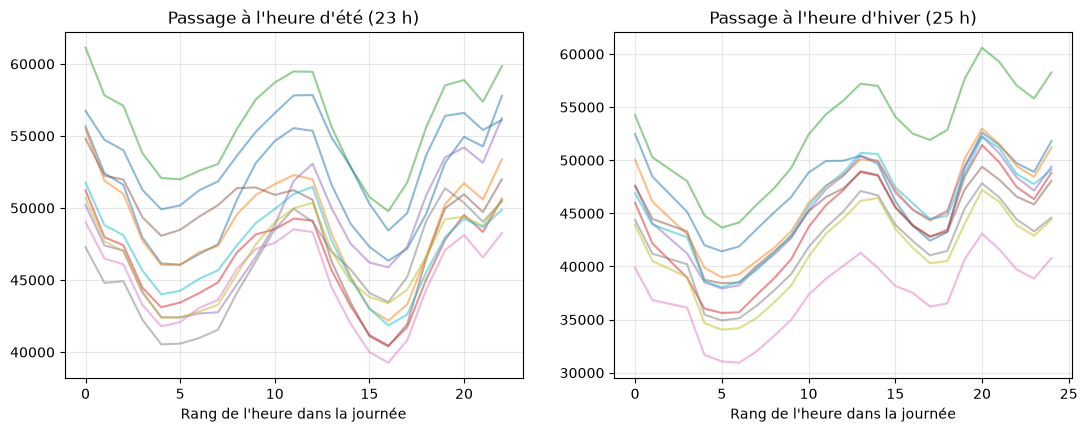

In [35]:
# Nombre d'heures par jour de Paris : 24 normalement, 23 au passage à l'heure d'été, 25 à l'heure d'hiver
cnt = df.groupby("date")["consommation_mw"].count()

# Premier et dernier jour sont tronqués (le fichier commence/finit à minuit UTC, pas à minuit Paris) : on les met de côté
print("Jours tronqués aux bornes :", cnt.iloc[[0, -1]].to_dict())
cnt = cnt.iloc[1:-1]

print(cnt.value_counts().sort_index())

bad  = cnt[cnt == 23]
good = cnt[cnt == 25]
print("Jours à 23 h (heure d'été) :", len(bad), [d.strftime("%Y-%m-%d") for d in bad.index])
print("Jours à 25 h (heure d'hiver) :", len(good), [d.strftime("%Y-%m-%d") for d in good.index])
print("Jours avec un nombre d'heures inattendu (hors 23/24/25) :", len(cnt[~cnt.isin([23, 24, 25])]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, jours_dst, titre in [(ax[0], bad.index, "Passage à l'heure d'été (23 h)"),
                            (ax[1], good.index, "Passage à l'heure d'hiver (25 h)")]:
    for d in jours_dst:
        conso_jour = df.loc[df["date"] == d, "consommation_mw"].values
        a.plot(range(len(conso_jour)), conso_jour, alpha=.5)
    a.set_title(titre)
    a.set_xlabel("Rang de l'heure dans la journée")
    a.grid(alpha=.3)
plt.show()

- Nombre d'heures par jour : 11 jours à 23 h (passage à l'heure d'été, 2016-2026), 10 jours à 25 h (passage à l'heure d'hiver, 2016-2025), 3 904 jours à 24 h, aucun nombre d'heures inattendu : le calendrier de Paris est cohérent, sans trou ni doublon. Premier (2016-01-01, 23 lignes) et dernier jour (2026-10-01, 2 lignes) sont tronqués par le découpage à minuit UTC. Les 21 jours de changement d'heure tombent tous un dimanche.

- Graphiques : profils de dimanche normaux, sans rupture visible. L'axe est le rang de l'heure, décalé d'une heure par rapport à l'horloge après le trou (23 h) ou le doublon (25 h).
